In [485]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
RHOS = [0.05, 0.5, 1, 2, 5]
STDS = [1, 3, 5, 10, 15]
PRUNE_PERCENTS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]

df = pd.read_csv("./src/flatness_post_pruning_mnist_complete.csv")
df.head()

,Loss,SAM Loss,Accuracy,Random Loss,Random std,trace,trace_per_param,eigval_0,eigval_1,eigval_2,...,eigval_7,eigval_8,eigval_9,prune_ratio,is_sam,rho,pruning_method,std,sam_gap,loss_gap
0,0.068870,0.051676,0.9806,0.003649,0.006656,10392.897779,0.102121,2121.040198,1573.254413,1044.671552,...,355.506158,300.870008,246.026342,0.0,False,0.05,NaN,NaN,-0.017194,-0.065221
1,0.068969,0.049651,0.9804,0.000341,0.002238,9606.789099,0.094397,1996.859448,1474.775854,936.727243,...,326.574482,282.928078,232.024118,0.1,False,0.05,l1_unstructured,1.0,-0.019318,-0.068627
2,0.068921,0.047517,0.9803,0.000298,0.002139,8884.803673,0.087303,1870.023486,1423.845721,929.958926,...,314.527535,275.761414,218.136017,0.2,False,0.05,l1_unstructured,1.0,-0.021404,-0.068624
3,0.069458,0.045837,0.9796,0.000250,0.002117,8340.882277,0.081958,1773.337866,1340.469305,872.691702,...,321.073122,264.687514,226.198727,0.3,False,0.05,l1_unstructured,1.0,-0.023621,-0.069207
4,0.069333,0.043325,0.9799,0.000087,0.001852,8481.181073,0.083337,1729.785657,1268.863452,790.310547,...,308.913773,255.664667,223.863190,0.4,False,0.05,l1_unstructured,1.0,-0.026009,-0.069246


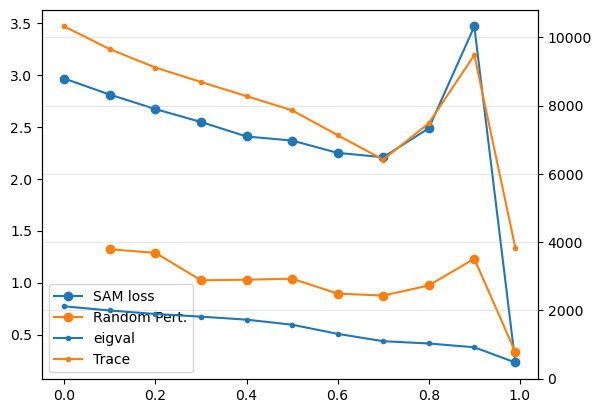

In [487]:
rho = 1
std = 5

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

summary = (
        df
        .groupby(["prune_ratio"])["eigval_0"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

# plot
x = summary["prune_ratio"]
y = summary["mean"]
yerr = summary["std"]
coeff = 0.2

ax2.plot(x, y, marker=".", label="eigval")
#plt.fill_between(x, y - coeff*yerr, y + coeff*yerr, alpha=0.2)

# group by "prune_ratio", "is_sam" to get avg (SAM Loss - Loss) and it's std
df["sam_gap"] = df["SAM Loss"] - df["Loss"]
df_rho = df[df["rho"]==rho]
summary = (
    df_rho
    .groupby(["prune_ratio"])["sam_gap"]
    .agg(mean="mean", std="std")
    .reset_index()
)
# plot
x = summary["prune_ratio"]
y = summary["mean"]
yerr = summary["std"]
coeff = 0.2
ax1.plot(x, y, marker="o", label="SAM loss")

df["loss_gap"] =  df["Random Loss"] - df["Loss"]
df_std = df[df["std"]==std]
summary = (
    df_std
    .groupby(["prune_ratio"])["Random Loss"]
    .agg(mean="mean", std="std")
    .reset_index()
)
# plot
x = summary["prune_ratio"]
y = summary["mean"] / summary["mean"].mean()
yerr = summary["std"]
coeff = 0.2

ax1.plot(x, y, marker="o", label="Random Pert.")

summary = (
        df
        .groupby(["prune_ratio"])["trace"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

# plot
x = summary["prune_ratio"]
y = summary["mean"]
yerr = summary["std"]
coeff = 0.2

ax2.plot(x, y, marker=".", label="Trace")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.xlabel("Prune Ratio")
plt.grid(True, alpha=0.3)

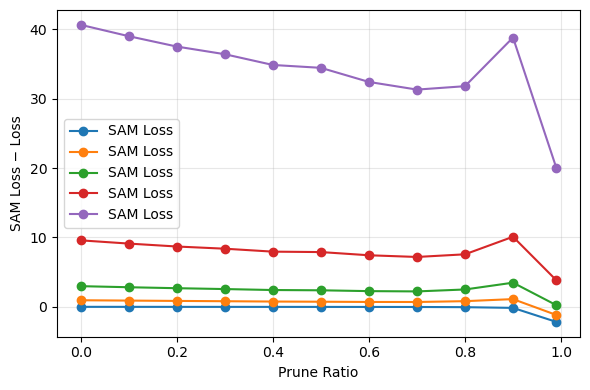

In [488]:
plt.figure(figsize=(6, 4))
for rho in RHOS:
    # group by "prune_ratio", "is_sam" to get avg (SAM Loss - Loss) and it's std
    df["sam_gap"] = df["SAM Loss"] - df["Loss"]
    df_rho = df[df["rho"]==rho]
    summary = (
        df_rho
        .groupby(["prune_ratio"])["sam_gap"]
        .agg(mean="mean", std="std")
        .reset_index()
    )
    # plot
    x = summary["prune_ratio"]
    y = summary["mean"]
    yerr = summary["std"]
    coeff = 0.2

    plt.plot(x, y, marker="o", label="SAM Loss")
    # plt.fill_between(x, y - coeff*yerr, y + coeff*yerr, alpha=0.2)

    plt.xlabel("Prune Ratio")
    plt.ylabel("SAM Loss − Loss")
    plt.grid(True, alpha=0.3)


plt.legend()
plt.tight_layout()
plt.show()


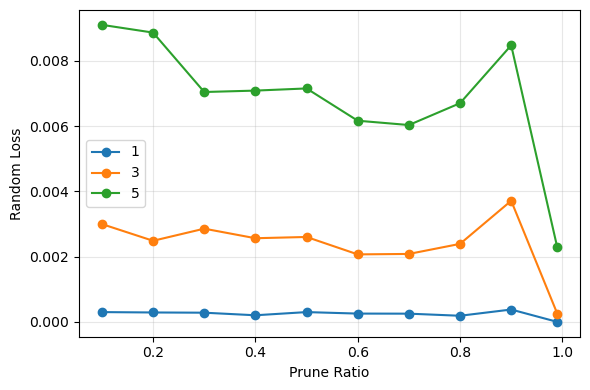

In [489]:
plt.figure(figsize=(6, 4))
for std in STDS[:-2]:
    # group by "prune_ratio", "is_sam" to get avg (SAM Loss - Loss) and it's std
    df["loss_gap"] =  df["Random Loss"] - df["Loss"]
    df_std = df[df["std"]==std]
    summary = (
        df_std
        .groupby(["prune_ratio"])["Random Loss"]
        .agg(mean="mean", std="std")
        .reset_index()
    )
    # plot
    x = summary["prune_ratio"]
    y = summary["mean"]
    yerr = summary["std"]
    coeff = 0.2

    plt.plot(x, y, marker="o", label=std)
    #plt.fill_between(x, y - coeff*yerr, y + coeff*yerr, alpha=0.2)

    plt.xlabel("Prune Ratio")
    plt.ylabel("Random Loss")
    plt.grid(True, alpha=0.3)

loss_summary = (
        df
        .groupby(["prune_ratio"])["Loss"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

# plot
# x = loss_summary["prune_ratio"]
# y = loss_summary["mean"]
# yerr = loss_summary["std"]
# coeff = 0.2

# plt.plot(x, y, marker="o", label="Loss")
# #plt.fill_between(x, y - coeff*yerr, y + coeff*yerr, alpha=0.2)

# plt.grid(True, alpha=0.3)
# plt.ylim((-0.1, 0.5))

plt.legend()
plt.tight_layout()
plt.show()


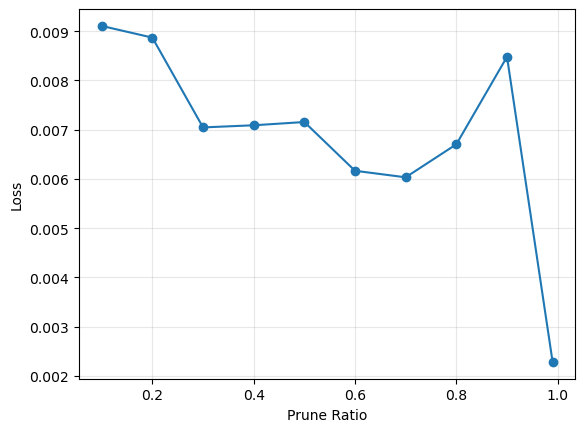

In [490]:
loss_summary = (
        df
        .groupby(["prune_ratio"])["Loss"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

# plot
x = summary["prune_ratio"]
y = summary["mean"]
yerr = summary["std"]
coeff = 0.2

plt.plot(x, y, marker="o")
#plt.fill_between(x, y - coeff*yerr, y + coeff*yerr, alpha=0.2)

plt.xlabel("Prune Ratio")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

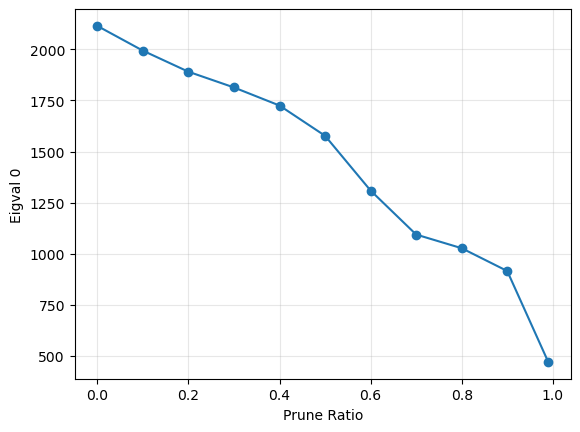

In [491]:
summary = (
        df
        .groupby(["prune_ratio"])["eigval_0"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

# plot
x = summary["prune_ratio"]
y = summary["mean"]
yerr = summary["std"]
coeff = 0.2

plt.plot(x, y, marker="o", label=std)
#plt.fill_between(x, y - coeff*yerr, y + coeff*yerr, alpha=0.2)

plt.xlabel("Prune Ratio")
plt.ylabel("Eigval 0")
plt.grid(True, alpha=0.3)

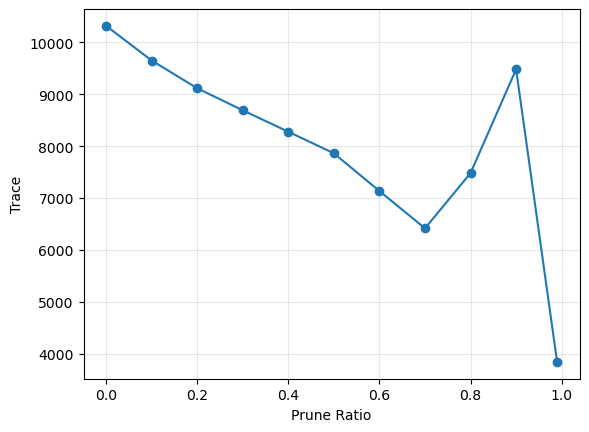

In [492]:
summary = (
        df
        .groupby(["prune_ratio"])["trace"]
        .agg(mean="mean", std="std")
        .reset_index()
    )

# plot
x = summary["prune_ratio"]
y = summary["mean"]
yerr = summary["std"]
coeff = 0.2

plt.plot(x, y, marker="o", label=std)
#plt.fill_between(x, y - coeff*yerr, y + coeff*yerr, alpha=0.2)

plt.xlabel("Prune Ratio")
plt.ylabel("Trace")
plt.grid(True, alpha=0.3)

Results for rho: 0.05


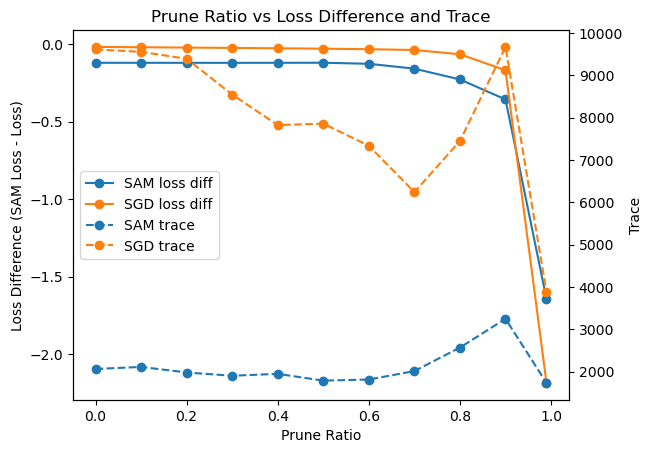

Results for rho: 0.5


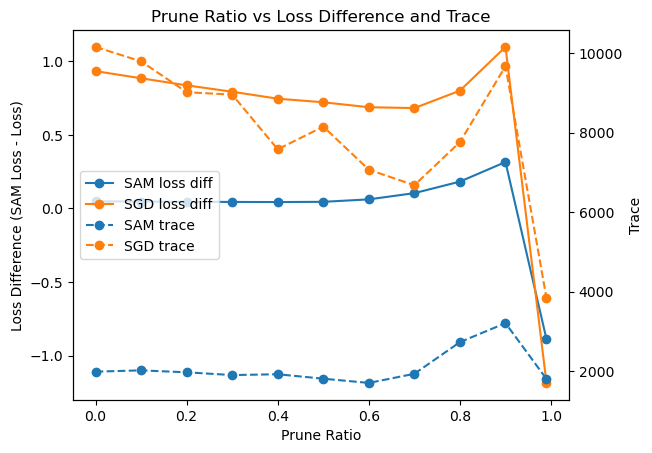

Results for rho: 1


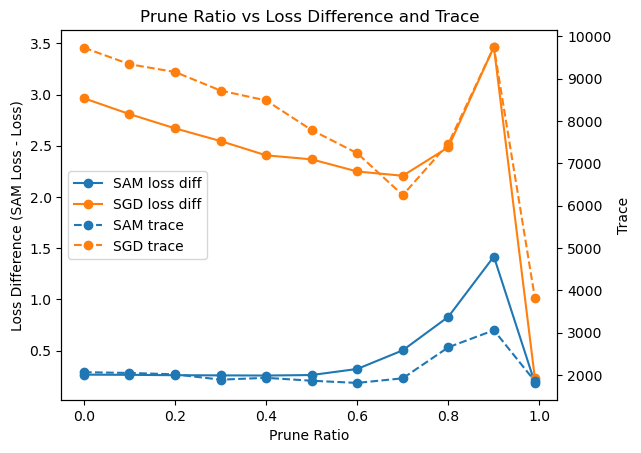

Results for rho: 2


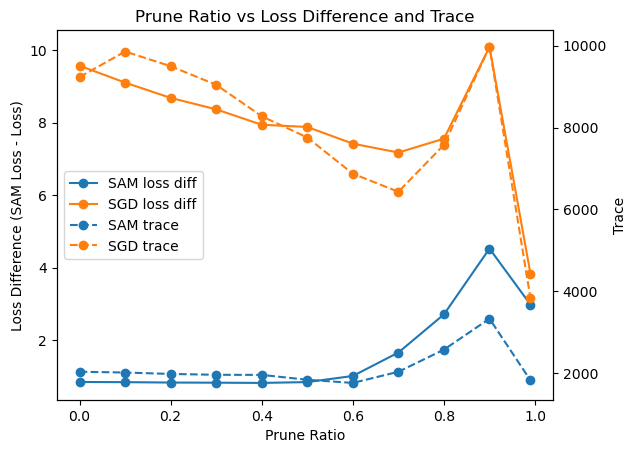

Results for rho: 5


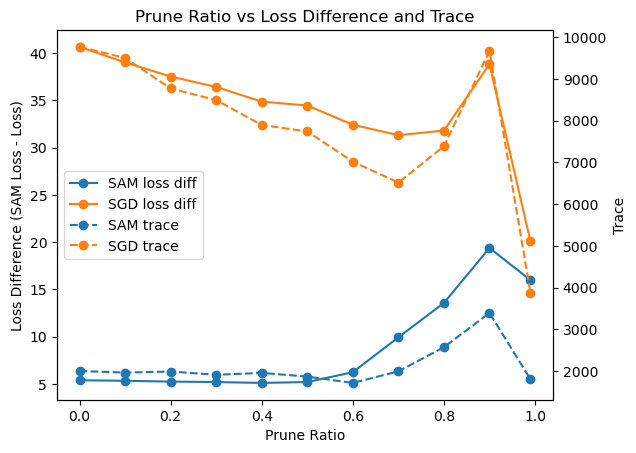

In [493]:
rhos = [0.05, 0.5, 1, 2, 5]
for rho in rhos:

    df = pd.read_csv(f"flatness_post_pruning_results_mnist_rho_{rho}_2.csv")
    df["loss_diff"] = df["SAM Loss"] - df["Loss"]
    print(f"Results for rho: {rho}")


    fig, ax1 = plt.subplots()

    # ----- Loss difference (left y-axis) -----
    ax1.plot(
        df[df["is_sam"] == True]["prune_ratio"],
        df[df["is_sam"] == True]["loss_diff"],
        label="SAM loss diff",
        marker='o'
    )

    ax1.plot(
        df[df["is_sam"] == False]["prune_ratio"],
        df[df["is_sam"] == False]["loss_diff"],
        label="SGD loss diff",
        marker='o'
    )

    ax1.set_xlabel("Prune Ratio")
    ax1.set_ylabel("Loss Difference (SAM Loss - Loss)")
    #ax1.grid(True)
    #ax1.set_ylim(-0.1, 1.2)

    # ----- Trace (right y-axis) -----
    ax2 = ax1.twinx()

    ax2.plot(
        df[df["is_sam"] == True]["prune_ratio"],
        df[df["is_sam"] == True]["trace"],
        label="SAM trace",
        marker='o',
        linestyle='--'
    )

    ax2.plot(
        df[df["is_sam"] == False]["prune_ratio"],
        df[df["is_sam"] == False]["trace"],
        label="SGD trace",
        marker='o',
        linestyle='--'
    )

    ax2.set_ylabel("Trace")

    # ----- Combined legend -----
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")

    plt.title("Prune Ratio vs Loss Difference and Trace")
    plt.savefig("mnist_sharpness_vs_pruning.pdf", dpi=300)
    plt.show()


Results for rho: 0.05


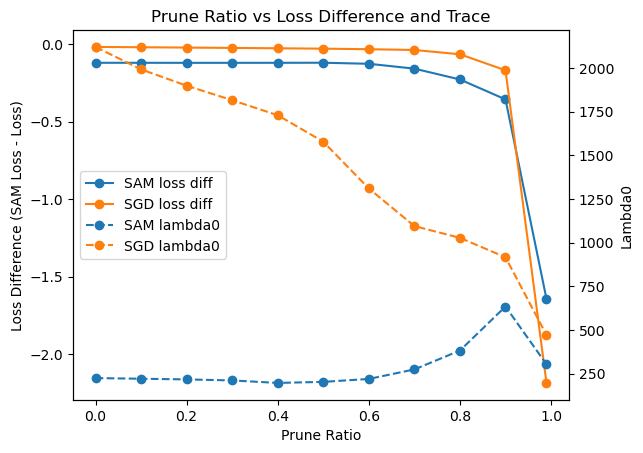

Results for rho: 0.5


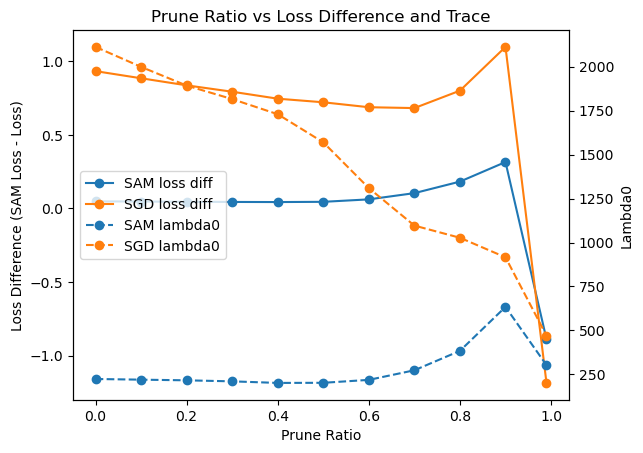

Results for rho: 1


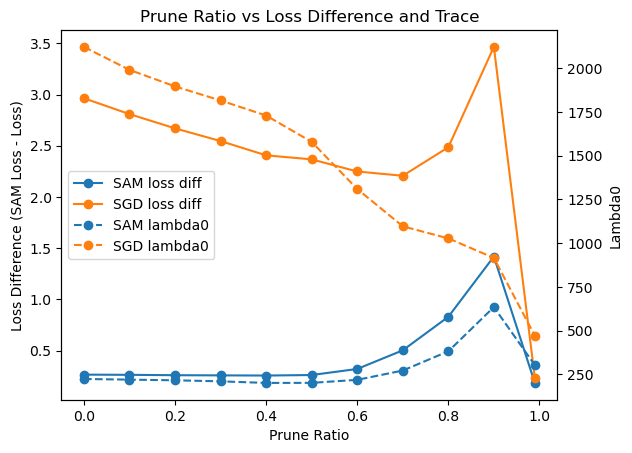

Results for rho: 2


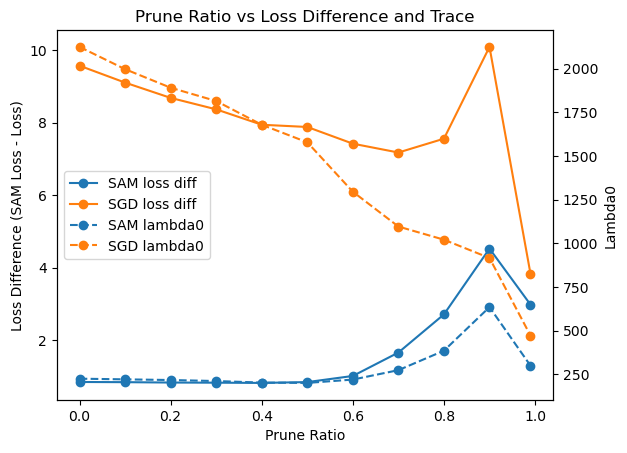

Results for rho: 5


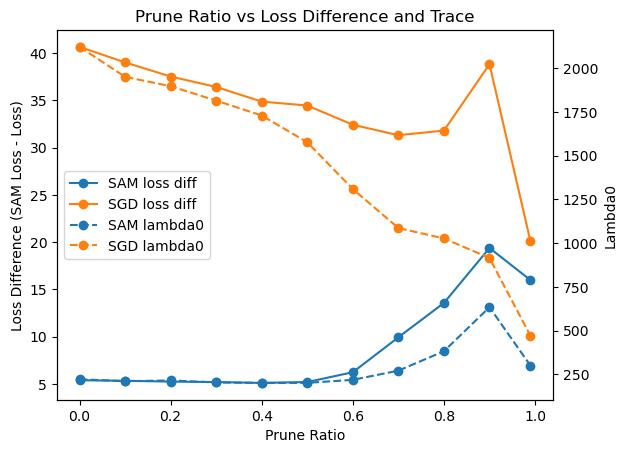

In [494]:
for rho in rhos:

    df = pd.read_csv(f"flatness_post_pruning_results_mnist_rho_{rho}_2.csv")
    df["loss_diff"] = df["SAM Loss"] - df["Loss"]
    print(f"Results for rho: {rho}")

    fig, ax1 = plt.subplots()

    # ----- Loss difference (left y-axis) -----
    ax1.plot(
        df[df["is_sam"] == True]["prune_ratio"],
        df[df["is_sam"] == True]["loss_diff"],
        label="SAM loss diff",
        marker='o'
    )

    ax1.plot(
        df[df["is_sam"] == False]["prune_ratio"],
        df[df["is_sam"] == False]["loss_diff"],
        label="SGD loss diff",
        marker='o'
    )

    ax1.set_xlabel("Prune Ratio")
    ax1.set_ylabel("Loss Difference (SAM Loss - Loss)")
    #ax1.grid(True)
    #ax1.set_ylim(-0.1, 1.2)

    # ----- Trace (right y-axis) -----
    ax2 = ax1.twinx()

    ax2.plot(
        df[df["is_sam"] == True]["prune_ratio"],
        df[df["is_sam"] == True]["eigval_0"],
        label="SAM lambda0",
        marker='o',
        linestyle='--'
    )

    ax2.plot(
        df[df["is_sam"] == False]["prune_ratio"],
        df[df["is_sam"] == False]["eigval_0"],
        label="SGD lambda0",
        marker='o',
        linestyle='--'
    )

    ax2.set_ylabel("Lambda0")

    # ----- Combined legend -----
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")

    plt.title("Prune Ratio vs Loss Difference and Trace")
    #plt.savefig("mnist_sharpness_vs_pruning.pdf", dpi=300)
    plt.show()


Results for rho: 1


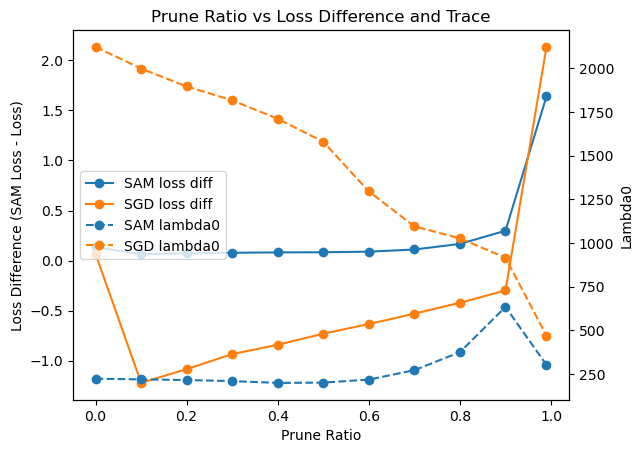

In [495]:
import os

for rho in rhos:
    if not os.path.exists(f"flatness_post_pruning_results_mnist_rho_{rho}_3.csv"):
        continue
    df = pd.read_csv(f"flatness_post_pruning_results_mnist_rho_{rho}_3.csv")
    df["loss_diff"] = df["Loss"] - df["Random Loss"]
    print(f"Results for rho: {rho}")

    fig, ax1 = plt.subplots()

    # ----- Loss difference (left y-axis) -----
    ax1.plot(
        df[df["is_sam"] == True]["prune_ratio"],
        df[df["is_sam"] == True]["loss_diff"],
        label="SAM loss diff",
        marker='o'
    )

    ax1.plot(
        df[df["is_sam"] == False]["prune_ratio"],
        df[df["is_sam"] == False]["loss_diff"],
        label="SGD loss diff",
        marker='o'
    )

    ax1.set_xlabel("Prune Ratio")
    ax1.set_ylabel("Loss Difference (SAM Loss - Loss)")
    #ax1.grid(True)
    #ax1.set_ylim(-0.5, 0.5)

    # ----- Trace (right y-axis) -----
    ax2 = ax1.twinx()

    ax2.plot(
        df[df["is_sam"] == True]["prune_ratio"],
        df[df["is_sam"] == True]["eigval_0"],
        label="SAM lambda0",
        marker='o',
        linestyle='--'
    )

    ax2.plot(
        df[df["is_sam"] == False]["prune_ratio"],
        df[df["is_sam"] == False]["eigval_0"],
        label="SGD lambda0",
        marker='o',
        linestyle='--'
    )

    ax2.set_ylabel("Lambda0")

    # ----- Combined legend -----
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")

    plt.title("Prune Ratio vs Loss Difference and Trace")
    #plt.savefig("mnist_sharpness_vs_pruning.pdf", dpi=300)
    plt.show()
